# Business Understanding

## Project Domain

Domain: Financial Technology (FinTech)
Sub-Domain: Credit Risk Assessment & Loan Decision Support Systems

Sistem prediksi kelayakan pinjaman (Loan Prediction System) merupakan bagian dari teknologi finansial modern yang memanfaatkan machine learning untuk membantu lembaga keuangan dalam menentukan apakah seorang pemohon layak mendapatkan pinjaman. Sistem ini mendukung proses pengambilan keputusan berbasis data, efisien, dan konsisten.

## Problem Statements

Masalah yang Dihadapi:

Proses Verifikasi Manual Memakan Waktu
Bank dan lembaga keuangan biasanya mengevaluasi permohonan pinjaman secara manual, yang tidak hanya memakan waktu tetapi juga rawan kesalahan subjektif.

Tingginya Risiko Gagal Bayar
Tanpa analisis data yang akurat, keputusan pemberian pinjaman berpotensi salah sasaran, yang menyebabkan kredit macet atau NPL (Non-Performing Loan).

Kurangnya Sistem Pendukung Keputusan Otomatis
Banyak lembaga keuangan skala kecil belum memiliki sistem berbasis data untuk mendukung keputusan kredit secara real-time.

## Goals

Membangun sistem prediksi otomatis untuk menentukan kelayakan pemohon pinjaman berdasarkan data demografis dan keuangan.

Meningkatkan akurasi dan efisiensi proses persetujuan pinjaman dengan pendekatan berbasis machine learning.

Menyediakan platform interaktif bagi petugas bank atau pengguna untuk menginput data calon peminjam dan langsung mendapatkan hasil prediksi.

Mengurangi risiko kredit dengan menolak permohonan dari profil berisiko tinggi sebelum terjadi default.

## Solution Statements

Aplikasi Web Interaktif (Streamlit)
Mengembangkan antarmuka berbasis web menggunakan Streamlit yang memungkinkan pengguna untuk memasukkan data pemohon dan melihat hasil prediksi secara instan.

Visualisasi dan Analisis Dataset
Menyediakan grafik dan insight yang mudah dipahami untuk menjelaskan tren dan distribusi data seperti pengaruh pendapatan, status pekerjaan, jenis kelamin, jumlah tanggungan terhadap hasil prediksi.

Evaluasi Model dan Akurasi
Menggunakan metrik evaluasi seperti accuracy, confusion matrix, dan classification report untuk menilai performa model dan meningkatkan akurasi prediksi hingga mencapai target (>80%).

# Data Understanding

## Import data dari kaggle

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"fazrisholihin12","key":"f64e8d24271d83ee93fe84dbd1dfad9e"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!ls ~/.kaggle

kaggle.json


In [ ]:
!kaggle datasets download -d ethicalstar/loan-prediction

Dataset URL: https://www.kaggle.com/datasets/ethicalstar/loan-prediction
License(s): apache-2.0


In [ ]:
!mkdir loan-prediction
!unzip loan-prediction.zip -d loan-prediction
!ls loan-prediction

Archive:  loan-prediction.zip
  inflating: loan-prediction/Loan Prediction.csv  
'Loan Prediction.csv'


## Import Library yang dibutuhkan

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import confusion_matrix, classification_report

## Exploratory Data Analysis

In [ ]:
df = pd.read_csv('/content/loan-prediction.zip')

In [ ]:
df.head()

,Id,Income,Age,Experience,Married/Single,House_Ownership,Car_Ownership,Profession,CITY,STATE,CURRENT_JOB_YRS,CURRENT_HOUSE_YRS,Risk_Flag
0,1,1303834,23,3,single,rented,no,Mechanical_engineer,Rewa,Madhya_Pradesh,3,13,0
1,2,7574516,40,10,single,rented,no,Software_Developer,Parbhani,Maharashtra,9,13,0
2,3,3991815,66,4,married,rented,no,Technical_writer,Alappuzha,Kerala,4,10,0
3,4,6256451,41,2,single,rented,yes,Software_Developer,Bhubaneswar,Odisha,2,12,1
4,5,5768871,47,11,single,rented,no,Civil_servant,Tiruchirappalli[10],Tamil_Nadu,3,14,1


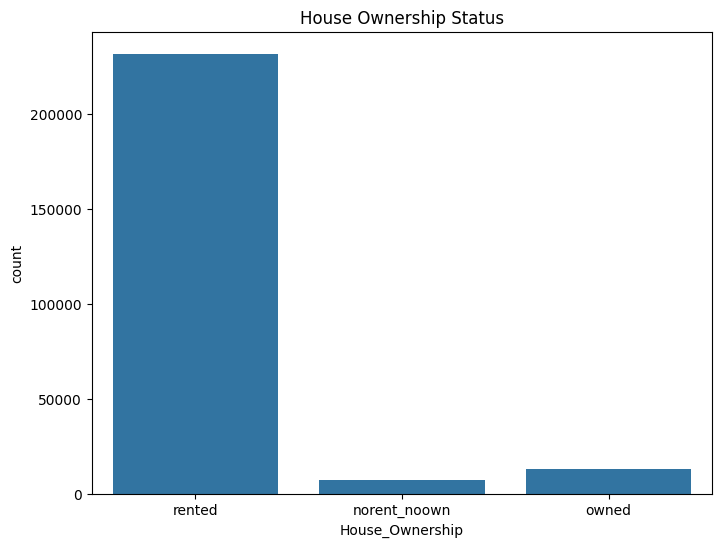

In [ ]:
# barplot of House Ownership status
plt.figure(figsize=(8, 6))
sns.countplot(x='House_Ownership', data=df)
plt.title('House Ownership Status')
plt.show()

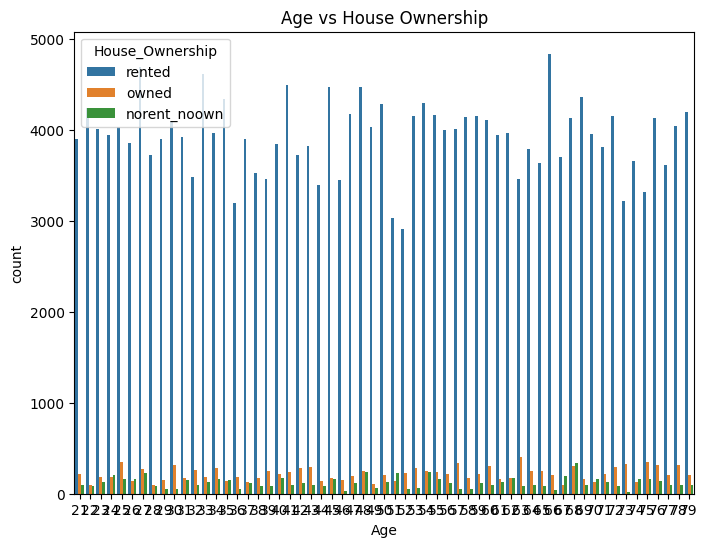

In [ ]:
# barplot of Age vs House Ownership
plt.figure(figsize=(8, 6))
sns.countplot(x='Age', hue='House_Ownership', data=df)
plt.title('Age vs House Ownership')
plt.show()

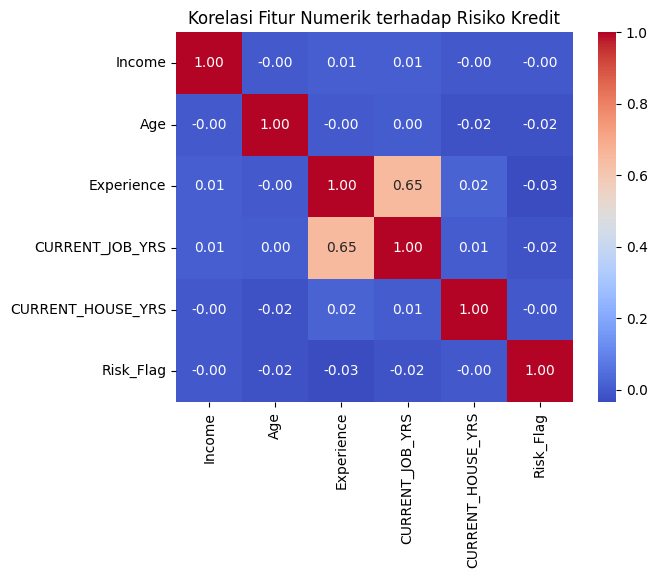

In [ ]:
# EDA 2: Korelasi fitur numerik terhadap Risk_Flag
numerical_cols = ['Income', 'Age', 'Experience', 'CURRENT_JOB_YRS', 'CURRENT_HOUSE_YRS']
plt.figure()
corr = df[numerical_cols + ['Risk_Flag']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Korelasi Fitur Numerik terhadap Risiko Kredit')
plt.show()

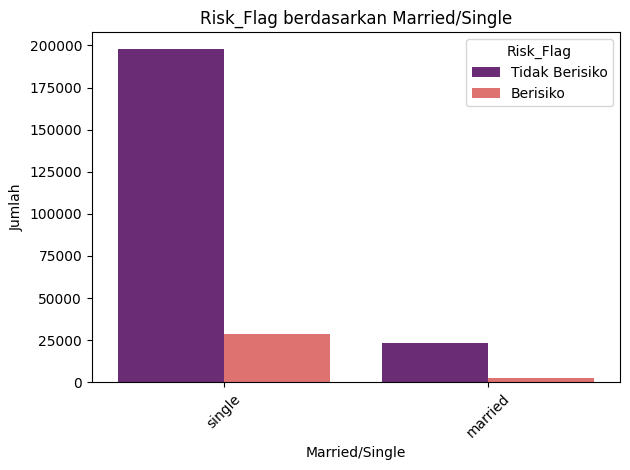

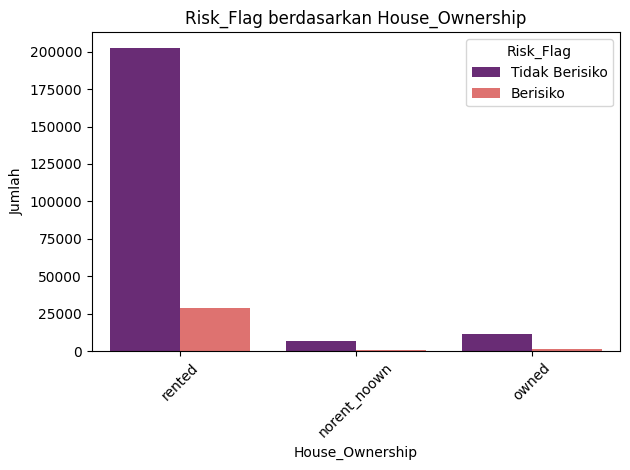

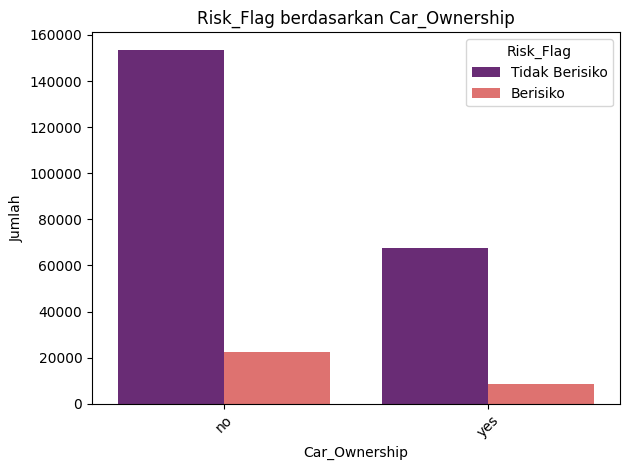

In [ ]:
categorical_cols = ['Married/Single', 'House_Ownership', 'Car_Ownership']
for col in categorical_cols:
    plt.figure()
    sns.countplot(x=col, hue='Risk_Flag', data=df, palette='magma')
    plt.title(f'Risk_Flag berdasarkan {col}')
    plt.ylabel('Jumlah')
    plt.legend(title='Risk_Flag', labels=['Tidak Berisiko', 'Berisiko'])
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


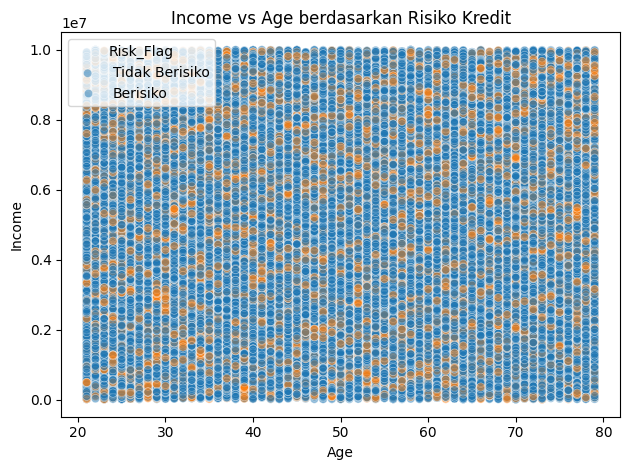

In [ ]:
# Scatter plot: Income vs Age dengan warna berdasarkan Risk_Flag
plt.figure()
sns.scatterplot(x='Age', y='Income', hue='Risk_Flag', data=df, alpha=0.5)
plt.title('Income vs Age berdasarkan Risiko Kredit')
plt.xlabel('Age')
plt.ylabel('Income')
plt.legend(title='Risk_Flag', labels=['Tidak Berisiko', 'Berisiko'])
plt.tight_layout()
plt.show()

# Data Preparation

In [ ]:
# pisahkan fitur dan target
X = df.drop(columns=["Risk_Flag"])
y = df["Risk_Flag"]

In [ ]:
df.head()

,Id,Income,Age,Experience,Married/Single,House_Ownership,Car_Ownership,Profession,CITY,STATE,CURRENT_JOB_YRS,CURRENT_HOUSE_YRS,Risk_Flag
0,1,1303834,23,3,single,rented,no,Mechanical_engineer,Rewa,Madhya_Pradesh,3,13,0
1,2,7574516,40,10,single,rented,no,Software_Developer,Parbhani,Maharashtra,9,13,0
2,3,3991815,66,4,married,rented,no,Technical_writer,Alappuzha,Kerala,4,10,0
3,4,6256451,41,2,single,rented,yes,Software_Developer,Bhubaneswar,Odisha,2,12,1
4,5,5768871,47,11,single,rented,no,Civil_servant,Tiruchirappalli[10],Tamil_Nadu,3,14,1


In [ ]:
# Encode label target
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [ ]:
# 1. Pisahkan fitur kategorikal dan numerik
categorical_columns = ['Married/Single', 'House_Ownership', 'Car_Ownership', 'Profession', 'CITY', 'STATE']
numeric_columns = ['Age', 'Id', 'Experience', 'CURRENT_JOB_YRS', 'CURRENT_HOUSE_YRS']

# 2. One-hot encode kategori
X_encoded = pd.get_dummies(X, columns=categorical_columns)

# 3. Normalisasi semua kolom hasil encode
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_encoded)

In [ ]:
# Bagi data menjadi train dan test set
X_train, X_test, y_train, y_test = train_test_split(X_scaled,
                                                    y_encoded,
                                                    test_size=0.2,
                                                    random_state=42)

# Modeling

In [ ]:
model = keras.Sequential([
    keras.Input(shape=(X_train.shape[1],)),
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(len(le.classes_), activation="softmax")
])

In [ ]:
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        52,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 63,010 (246.13 KB)

 Trainable params: 63,010 (246.13 KB)

 Non-trainable params: 0 (0.00 B)

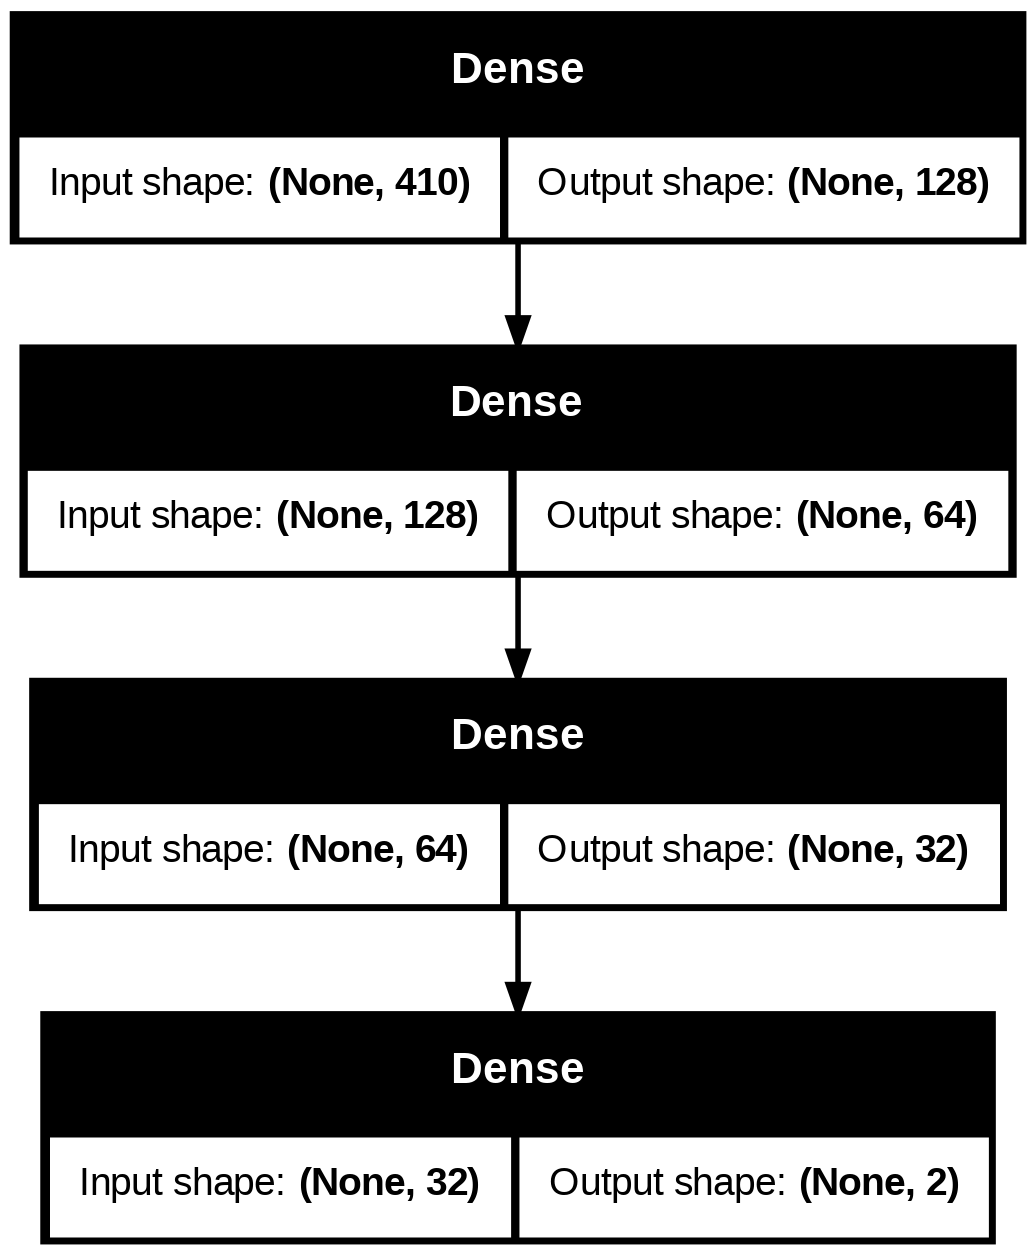

In [ ]:
from tensorflow.keras.utils import plot_model
plot_model(model, show_shapes = True)

In [ ]:
history = model.fit(X_train, y_train,
                    epochs=5,
                    batch_size=16,
                    validation_data=(X_test, y_test))

Epoch 1/5
12600/12600 ━━━━━━━━━━━━━━━━━━━━ 36s 3ms/step - accuracy: 0.8802 - loss: 0.3354 - val_accuracy: 0.8960 - val_loss: 0.2291
Epoch 2/5
12600/12600 ━━━━━━━━━━━━━━━━━━━━ 45s 3ms/step - accuracy: 0.8998 - loss: 0.2143 - val_accuracy: 0.9005 - val_loss: 0.2119
Epoch 3/5
12600/12600 ━━━━━━━━━━━━━━━━━━━━ 37s 3ms/step - accuracy: 0.9039 - loss: 0.1960 - val_accuracy: 0.9008 - val_loss: 0.2071
Epoch 4/5
12600/12600 ━━━━━━━━━━━━━━━━━━━━ 39s 3ms/step - accuracy: 0.9054 - loss: 0.1881 - val_accuracy: 0.9019 - val_loss: 0.2038
Epoch 5/5
12600/12600 ━━━━━━━━━━━━━━━━━━━━ 46s 3ms/step - accuracy: 0.9084 - loss: 0.1809 - val_accuracy: 0.9019 - val_loss: 0.2050


# Evaluation

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f'Test Accuracy: {test_acc}')
print(f'Test Loss: {test_loss}')

1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9019 - loss: 0.2033
Test Accuracy: 0.9019047617912292
Test Loss: 0.20501521229743958


In [ ]:
# Prediksi
y_pred = model.predict(X_test)

# Ubah prediksi probabilitas jadi kelas (0 atau 1)
# Get the class with the highest probability
y_pred_classes = np.argmax(y_pred, axis=1)

# Jika y_test juga probabilitas atau one-hot, ubah ke label (kelas)
# Tapi jika y_test sudah dalam bentuk label 0/1, cukup langsung pakai
y_test_classes = y_test  # Pastikan y_test sudah dalam bentuk label

# Evaluasi hasil
from sklearn.metrics import confusion_matrix, classification_report

print("Confusion Matrix:")
print(confusion_matrix(y_test_classes, y_pred_classes))

print("\nClassification Report:")
print(classification_report(y_test_classes, y_pred_classes))

1575/1575 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
Confusion Matrix:
[[42629  1518]
 [ 3426  2827]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.97      0.95     44147
           1       0.65      0.45      0.53      6253

    accuracy                           0.90     50400
   macro avg       0.79      0.71      0.74     50400
weighted avg       0.89      0.90      0.89     50400



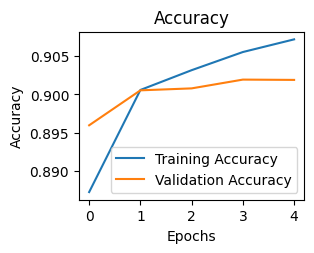

In [ ]:
plt.subplot(2, 2, 4)
plt.plot(history.history["accuracy"], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy')

plt.show()

# Deployment

## Model Simulation

In [ ]:
sample_input = np.array([[0.437526, 1.013637 ,1, 2, 0,	43, 227, 12, -0.731036, 0.716256,0]])
sample_input_df = pd.DataFrame(sample_input)

In [ ]:
column_names = X_encoded.columns

# Reindex the sample input DataFrame
sample_input_df = sample_input_df.reindex(columns=column_names, fill_value=0)

# Transform the sample input
sample_input_scaled = scaler.transform(sample_input_df)

In [ ]:
prediction = model.predict(sample_input_scaled)

# Get the predicted class
predicted_class = np.argmax(prediction)

# Get the prediction probability for the predicted class
predicted_probability = prediction[0][predicted_class]

# Get the class label using inverse_transform
predicted_crop = le.inverse_transform([predicted_class])

# Print the results
print(f"Estimasi Prediksi (Probabilitas): {predicted_probability}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
Estimasi Prediksi (Probabilitas): 0.9206075072288513


## Save Model

In [ ]:
# Konversi model ke TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Simpan model
with open('loan_prediction.tflite', 'wb') as f:
    f.write(tflite_model)

Saved artifact at '/tmp/tmpvqgp2a4x'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 410), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  138347675085584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138347675086736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138347675085008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138347675087504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138347675082128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138347675088656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138347675083472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138347675086544: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [ ]:
# Simpan label encoder dan scaler
import joblib
joblib.dump(le, 'label_encoder.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [ ]:
from sklearn.preprocessing import OneHotEncoder
import joblib

# Assuming 'categorical_columns' is defined as in your original code
categorical_columns = ['Married/Single', 'House_Ownership', 'Car_Ownership', 'Profession', 'CITY', 'STATE']

# Create and fit the OneHotEncoder
enc = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
enc.fit(X[categorical_columns])

# Save the encoder
joblib.dump(enc, 'encoder.pkl')


['encoder.pkl']